# Convolutional Neural Networks

## Learning Objectives

1. **Explain** the motivation for CNNs: local connectivity, weight sharing, translation equivariance
2. **Define** a convolutional layer: filter, activation map, stride $s$, zero padding $p$
3. **Derive** the output size formula: $n_\text{out} = \lfloor(n_\text{in} - f + 2p)/s\rfloor + 1$
4. **Describe** max pooling and its role in spatial downsampling
5. **Trace** a VGGNet-style architecture: alternating conv+ReLU blocks, doubling filters, global average pool
6. **Implement** a 2D convolution and max pooling from scratch using NumPy


## Problem Statement

### Why Not Just Use Fully Connected Layers?

A $256 \times 256$ RGB image has $256^2 \times 3 = 196{,}608$ pixels. A single fully connected hidden layer with 1000 units would require $\sim 196M$ parameters — wasteful and prone to overfitting. Images have two key structural properties that CNNs exploit:

1. **Local structure**: nearby pixels are more correlated than distant ones
2. **Translation invariance**: a cat is a cat regardless of where it appears in the image

### Convolutional Layer

A **filter** (kernel) $W \in \mathbb{R}^{f \times f \times C_{\text{in}}}$ slides over the input $X \in \mathbb{R}^{H \times W \times C_{\text{in}}}$ with stride $s$ and padding $p$, producing an **activation map** (feature map):

$$A[i, j] = \sum_{u=0}^{f-1}\sum_{v=0}^{f-1}\sum_{c=0}^{C_{\text{in}}-1} W[u,v,c] \cdot X[si+u-p,\, sj+v-p,\, c] + b$$

**Output size:**
$$n_\text{out} = \left\lfloor \frac{n_\text{in} - f + 2p}{s} \right\rfloor + 1$$

Using $C_{\text{out}}$ filters produces a $H' \times W' \times C_{\text{out}}$ output. Parameters per layer: $f^2 \cdot C_{\text{in}} \cdot C_{\text{out}} + C_{\text{out}}$.

### Max Pooling

Downsamples spatial dimensions by taking the maximum over non-overlapping (or strided) windows:
$$P[i,j] = \max_{0 \leq u,v < p} A[pi+u,\, pj+v]$$

Reduces $H \times W$ to $\lfloor H/p \rfloor \times \lfloor W/p \rfloor$. No learnable parameters.


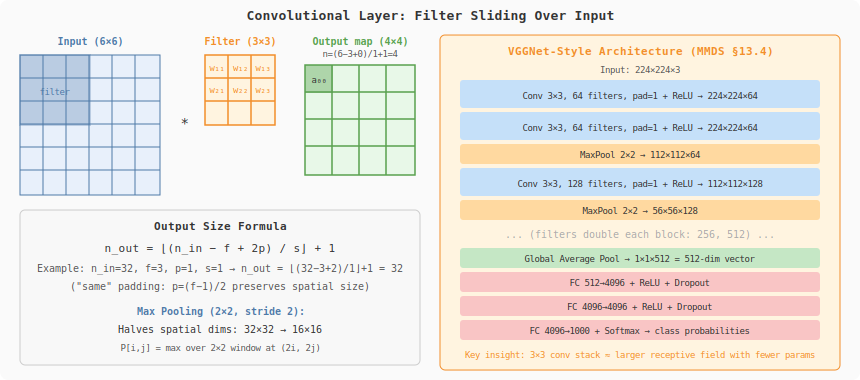

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="380" font-family="monospace" font-size="11">
  <rect width="860" height="380" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Convolutional Layer: Filter Sliding Over Input</text>

  <!-- Input grid 6x6 -->
  <text x="90" y="45" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">Input (6×6)</text>
  <g stroke="#4e79a7" stroke-width="1" fill="#e8f0fb">
    <rect x="20" y="55" width="140" height="140"/>
    <!-- grid lines -->
    <line x1="43" y1="55" x2="43" y2="195"/><line x1="66" y1="55" x2="66" y2="195"/>
    <line x1="89" y1="55" x2="89" y2="195"/><line x1="112" y1="55" x2="112" y2="195"/>
    <line x1="135" y1="55" x2="135" y2="195"/>
    <line x1="20" y1="78" x2="160" y2="78"/><line x1="20" y1="101" x2="160" y2="101"/>
    <line x1="20" y1="124" x2="160" y2="124"/><line x1="20" y1="147" x2="160" y2="147"/>
    <line x1="20" y1="170" x2="160" y2="170"/>
  </g>
  <!-- Highlight 3x3 receptive field -->
  <rect x="20" y="55" width="70" height="70" fill="#4e79a7" opacity="0.3" stroke="#4e79a7" stroke-width="2"/>
  <text x="55" y="95" text-anchor="middle" fill="#4e79a7" font-size="9">filter</text>

  <!-- Arrow -->
  <text x="185" y="128" text-anchor="middle" fill="#333" font-size="14">*</text>

  <!-- Filter 3x3 -->
  <text x="240" y="45" text-anchor="middle" fill="#f28e2b" font-size="10" font-weight="bold">Filter (3×3)</text>
  <g stroke="#f28e2b" stroke-width="1.5" fill="#fff4e0">
    <rect x="205" y="55" width="70" height="70"/>
    <line x1="228" y1="55" x2="228" y2="125"/><line x1="251" y1="55" x2="251" y2="125"/>
    <line x1="205" y1="78" x2="275" y2="78"/><line x1="205" y1="101" x2="275" y2="101"/>
  </g>
  <text x="217" y="71" text-anchor="middle" fill="#f28e2b" font-size="9">w₁₁</text>
  <text x="240" y="71" text-anchor="middle" fill="#f28e2b" font-size="9">w₁₂</text>
  <text x="263" y="71" text-anchor="middle" fill="#f28e2b" font-size="9">w₁₃</text>
  <text x="217" y="93" text-anchor="middle" fill="#f28e2b" font-size="9">w₂₁</text>
  <text x="240" y="93" text-anchor="middle" fill="#f28e2b" font-size="9">w₂₂</text>
  <text x="263" y="93" text-anchor="middle" fill="#f28e2b" font-size="9">w₂₃</text>

  <!-- Output grid 4x4 -->
  <text x="360" y="45" text-anchor="middle" fill="#59a14f" font-size="10" font-weight="bold">Output map (4×4)</text>
  <text x="360" y="57" text-anchor="middle" fill="#555" font-size="9">n=(6−3+0)/1+1=4</text>
  <g stroke="#59a14f" stroke-width="1.5" fill="#e8f8e8">
    <rect x="305" y="65" width="110" height="110"/>
    <line x1="332" y1="65" x2="332" y2="175"/><line x1="359" y1="65" x2="359" y2="175"/><line x1="386" y1="65" x2="386" y2="175"/>
    <line x1="305" y1="92" x2="415" y2="92"/><line x1="305" y1="119" x2="415" y2="119"/><line x1="305" y1="146" x2="415" y2="146"/>
  </g>
  <rect x="305" y="65" width="28" height="28" fill="#59a14f" opacity="0.4"/>
  <text x="319" y="83" text-anchor="middle" fill="#333" font-size="9">a₀₀</text>

  <!-- Size formula -->
  <rect x="20" y="210" width="400" height="155" rx="5" fill="#f8f8f8" stroke="#ccc"/>
  <text x="220" y="230" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Output Size Formula</text>
  <text x="220" y="252" text-anchor="middle" fill="#333" font-size="11">n_out = ⌊(n_in − f + 2p) / s⌋ + 1</text>
  <text x="220" y="272" text-anchor="middle" fill="#555" font-size="10">Example: n_in=32, f=3, p=1, s=1 → n_out = ⌊(32−3+2)/1⌋+1 = 32</text>
  <text x="220" y="290" text-anchor="middle" fill="#555" font-size="10">("same" padding: p=(f−1)/2 preserves spatial size)</text>
  <text x="220" y="315" text-anchor="middle" fill="#4e79a7" font-size="10" font-weight="bold">Max Pooling (2×2, stride 2):</text>
  <text x="220" y="333" text-anchor="middle" fill="#333" font-size="10">Halves spatial dims: 32×32 → 16×16</text>
  <text x="220" y="351" text-anchor="middle" fill="#555" font-size="9">P[i,j] = max over 2×2 window at (2i, 2j)</text>

  <!-- VGGNet architecture sketch -->
  <rect x="440" y="35" width="400" height="335" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="640" y="55" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">VGGNet-Style Architecture (MMDS §13.4)</text>
  <text x="640" y="73" text-anchor="middle" fill="#555" font-size="9">Input: 224×224×3</text>

  <rect x="460" y="80"  width="360" height="28" rx="3" fill="#c5e0f9"/><text x="640" y="99"  text-anchor="middle" fill="#333" font-size="9">Conv 3×3, 64 filters, pad=1 + ReLU  →  224×224×64</text>
  <rect x="460" y="112" width="360" height="28" rx="3" fill="#c5e0f9"/><text x="640" y="131" text-anchor="middle" fill="#333" font-size="9">Conv 3×3, 64 filters, pad=1 + ReLU  →  224×224×64</text>
  <rect x="460" y="144" width="360" height="20" rx="3" fill="#ffd9a0"/><text x="640" y="158" text-anchor="middle" fill="#333" font-size="9">MaxPool 2×2  →  112×112×64</text>

  <rect x="460" y="168" width="360" height="28" rx="3" fill="#c5e0f9"/><text x="640" y="187" text-anchor="middle" fill="#333" font-size="9">Conv 3×3, 128 filters, pad=1 + ReLU  →  112×112×128</text>
  <rect x="460" y="200" width="360" height="20" rx="3" fill="#ffd9a0"/><text x="640" y="214" text-anchor="middle" fill="#333" font-size="9">MaxPool 2×2  →  56×56×128</text>

  <text x="640" y="238" text-anchor="middle" fill="#aaa" font-size="10">... (filters double each block: 256, 512) ...</text>

  <rect x="460" y="248" width="360" height="20" rx="3" fill="#c5e7c5"/><text x="640" y="262" text-anchor="middle" fill="#333" font-size="9">Global Average Pool  →  1×1×512 = 512-dim vector</text>
  <rect x="460" y="272" width="360" height="20" rx="3" fill="#f9c5c5"/><text x="640" y="286" text-anchor="middle" fill="#333" font-size="9">FC 512→4096 + ReLU + Dropout</text>
  <rect x="460" y="296" width="360" height="20" rx="3" fill="#f9c5c5"/><text x="640" y="310" text-anchor="middle" fill="#333" font-size="9">FC 4096→4096 + ReLU + Dropout</text>
  <rect x="460" y="320" width="360" height="20" rx="3" fill="#f9c5c5"/><text x="640" y="334" text-anchor="middle" fill="#333" font-size="9">FC 4096→1000 + Softmax  →  class probabilities</text>
  <text x="640" y="358" text-anchor="middle" fill="#f28e2b" font-size="9">Key insight: 3×3 conv stack ≈ larger receptive field with fewer params</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Parameter Efficiency of Small Filters

Two stacked $3 \times 3$ conv layers have an effective receptive field of $5 \times 5$, but only $2 \times (3^2 C) = 18C$ parameters vs $5^2 C = 25C$ for a single $5 \times 5$ layer. More non-linearities also increase expressiveness.

### Convolution as Matrix Multiplication

A convolution with filter $W$ can be written as a matrix-vector product $\text{im2col}(X) \cdot \text{vec}(W)$, where `im2col` lays out all filter-sized patches as rows. This lets libraries use optimised BLAS routines (GEMM) for the forward pass.

### Backprop Through a Conv Layer

Let $\delta = \partial L / \partial A$ be the gradient of the loss w.r.t. the output map. Then:
- **Weight gradient**: $\partial L/\partial W = \text{correlate}(X, \delta)$ — correlate input with output gradient
- **Input gradient**: $\partial L/\partial X = \text{full convolution}(\delta, W_{\text{flipped}})$ — full (padded) convolution of gradient with flipped filter

### Pooling Backward

Max pooling routes the gradient only to the position that achieved the maximum in the forward pass (max-index mask). Avg pooling distributes gradient uniformly.


In [2]:
import numpy as np


def conv2d(X, W, b=0, stride=1, padding=0):
    """
    2D convolution (single channel in/out for clarity).
    X: (H, W)  W: (f, f)  b: scalar
    """
    H, Ww = X.shape
    f = W.shape[0]
    if padding > 0:
        X = np.pad(X, padding)
    H_out = (X.shape[0] - f) // stride + 1
    W_out = (X.shape[1] - f) // stride + 1
    A = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            A[i, j] = (X[i*stride:i*stride+f, j*stride:j*stride+f] * W).sum() + b
    return A


def max_pool2d(X, pool_size=2, stride=2):
    """2D max pooling."""
    H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    P = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            P[i, j] = X[i*stride:i*stride+pool_size,
                        j*stride:j*stride+pool_size].max()
    return P


def avg_pool2d(X, pool_size=2, stride=2):
    H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    P = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            P[i, j] = X[i*stride:i*stride+pool_size,
                        j*stride:j*stride+pool_size].mean()
    return P


# ── Example: edge-detection filter ────────────────────────────────────────────
X = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# Vertical edge detector (Sobel)
W_sobel = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)

A = conv2d(X, W_sobel, stride=1, padding=1)
P = max_pool2d(np.abs(A), pool_size=2, stride=2)

print("Input (8×8):")
print(X.astype(int))
print(f"\nOutput activation map (8×8 with padding=1):")
print(A.astype(int))
print(f"\nAfter max pool 2×2 (4×4):")
print(P.astype(int))

# ── Output size formula verification ──────────────────────────────────────────
print("\nOutput size formula: (n - f + 2p) // s + 1")
for n_in, f, p, s in [(8, 3, 1, 1), (32, 3, 1, 1), (32, 3, 0, 1), (32, 5, 2, 1), (224, 3, 1, 2)]:
    n_out = (n_in - f + 2*p) // s + 1
    print(f"  n={n_in:3d}, f={f}, p={p}, s={s} → n_out={n_out}")


Input (8×8):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]

Output activation map (8×8 with padding=1):
[[ 0  0  0  0  0  0  0  0]
 [ 0  1  1  0  0 -1 -1  0]
 [ 0  3  3  0  0 -3 -3  0]
 [ 0  4  4  0  0 -4 -4  0]
 [ 0  4  4  0  0 -4 -4  0]
 [ 0  3  3  0  0 -3 -3  0]
 [ 0  1  1  0  0 -1 -1  0]
 [ 0  0  0  0  0  0  0  0]]

After max pool 2×2 (4×4):
[[1 1 1 1]
 [4 4 4 4]
 [4 4 4 4]
 [1 1 1 1]]

Output size formula: (n - f + 2p) // s + 1
  n=  8, f=3, p=1, s=1 → n_out=8
  n= 32, f=3, p=1, s=1 → n_out=32
  n= 32, f=3, p=0, s=1 → n_out=30
  n= 32, f=5, p=2, s=1 → n_out=32
  n=224, f=3, p=1, s=2 → n_out=112


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# Visualise the convolution
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

filters = {
    'Vertical Edge\n(Sobel)': np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float),
    'Horizontal Edge\n(Sobel)': np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float),
    'Blur (3×3 avg)': np.ones((3,3), dtype=float)/9,
    'Sharpening': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float),
}

# Synthetic "image"
rng = np.random.default_rng(0)
base = np.zeros((20,20))
base[5:15, 5:15] = 1.0
base[8:12, 0:20] = 0.5

for ax, (name, W_f) in zip(axes, filters.items()):
    out = conv2d(base, W_f, stride=1, padding=1)
    ax.imshow(out, cmap='RdBu', vmin=-2, vmax=2)
    ax.set_title(name, fontsize=9)
    ax.axis('off')

fig.suptitle('Effect of Different 3×3 Filters on a Synthetic Image', fontsize=11)
fig.tight_layout()
plt.savefig('cnn_filters.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")


Figure saved.


/tmp/ipykernel_305642/111879128.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
